In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/bank.csv")

In [2]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [4]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [5]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [8]:
import sys
print(sys.executable)

d:\jupiter botebook anaconda\envs\mlops\python.exe


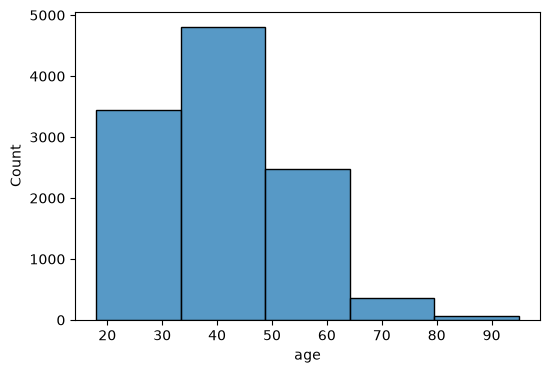

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize= (6, 4))
sns.histplot(df['age'], bins= 5, kde= False)
plt.show()

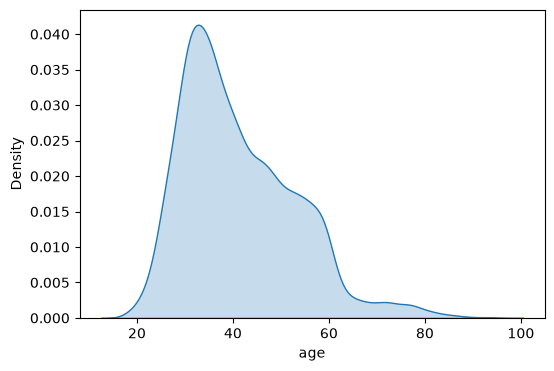

In [10]:
plt.figure(figsize= (6, 4))
sns.kdeplot(df['age'], fill= True)
plt.show()

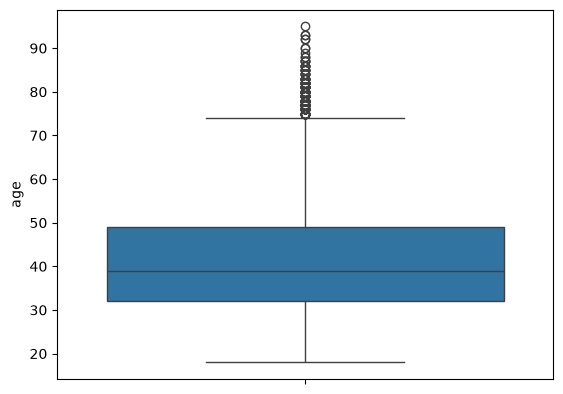

In [11]:
sns.boxplot(df['age'])
plt.show()

In [12]:
num_cols= df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
  q1= df[col].quantile(0.25)
  q3= df[col].quantile(0.75)
  iqr= q3-q1

  lower_limit= q1-1.5 *iqr
  upper_limit= q3+1.5 *iqr

  outliers= df[(df[col]<lower_limit) | (df[col]> upper_limit)]
  print(f'Outliers in {col}:')
  print(outliers)


Outliers in age:
       age      job   marital  education default  balance housing loan  \
1162    75  retired  divorced    primary      no     3881     yes   no   
1236    85  retired   married    primary      no    12114      no   no   
1243    90  retired  divorced  secondary      no        1      no   no   
1274    85  retired  divorced    primary      no     7613      no   no   
1320    83  retired  divorced    primary      no     1097      no   no   
...    ...      ...       ...        ...     ...      ...     ...  ...   
10438   77  retired   married    primary      no     1492      no   no   
10562   88  retired   married    primary      no      648      no   no   
10570   77  unknown   married    unknown      no      397      no   no   
10618   78  retired   married    primary      no      680      no   no   
10843   86  retired  divorced    unknown      no      157      no   no   

         contact  day month  duration  campaign  pdays  previous poutcome  \
1162    cellular 

In [13]:
df[num_cols].skew().sort_index(ascending= False)

previous    7.335298
pdays       2.449986
duration    2.143695
day         0.111330
campaign    5.545578
balance     8.224619
age         0.862780
dtype: float64

In [14]:
corr_matrix= df[num_cols].corr()
corr_matrix

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.112300,-0.000762,0.000189,-0.005278,0.002774,0.020169
balance,0.112300,1.000000,0.010467,0.022436,-0.013894,0.017411,0.030805
day,-0.000762,0.010467,1.000000,-0.018511,0.137007,-0.077232,-0.058981
duration,0.000189,0.022436,-0.018511,1.000000,-0.041557,-0.027392,-0.026716
campaign,-0.005278,-0.013894,0.137007,-0.041557,1.000000,-0.102726,-0.049699
pdays,0.002774,0.017411,-0.077232,-0.027392,-0.102726,1.000000,0.507272
previous,0.020169,0.030805,-0.058981,-0.026716,-0.049699,0.507272,1.000000


In [15]:
cat_cols= df.select_dtypes(include= ['object']).columns
cat_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'deposit'],
      dtype='object')

In [16]:
df['deposit']= df['deposit'].map({'no': 0, 'yes': 1})

In [17]:
corr_target = df.corr(numeric_only=True)['deposit'].sort_values(ascending=False)
corr_target

deposit     1.000000
duration    0.451919
pdays       0.151593
previous    0.139867
balance     0.081129
age         0.034901
day        -0.056326
campaign   -0.128081
Name: deposit, dtype: float64

In [18]:
print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')


In [19]:
print(df.dtypes)

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit       int64
dtype: object


In [20]:
from sklearn.model_selection import train_test_split

X= df.drop('deposit', axis= 1)
y= df['deposit']

X_train, X_test, y_train, y_test= train_test_split(X,y, test_size= 0.2, random_state= 42)

In [21]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

num_cols= [
    'age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'
]
ordinal_cols= [
    'education'
]
onehot_cols= [
    'marital', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'job'
]

num_pipeline= Pipeline([
    ('impute', SimpleImputer(strategy= 'median')),
    ('scale', StandardScaler())
])

ordinal_pipeline= Pipeline([
    ('impute', SimpleImputer(strategy= 'most_frequent')),
    ('encode', OrdinalEncoder())
])

onehot_pipeline= Pipeline([
    ('impute', SimpleImputer(strategy= 'most_frequent')),
    ('encode', OneHotEncoder())
])



preprocessing= ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('ordnial', ordinal_pipeline, ordinal_cols),
    ('onehot', onehot_pipeline, onehot_cols)
])

pipeline= Pipeline([
    ('preprocessing', preprocessing),
    ('model', DecisionTreeClassifier(random_state= 42))
])

param_grid = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [5, 10],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}
dt_grid= GridSearchCV(
    estimator= pipeline,
    param_grid= param_grid,
    cv= 5,
    scoring= 'accuracy',
    n_jobs= -1
)

dt_grid.fit(X_train, y_train)

print('best parameters:')
print(dt_grid.best_params_)


print('Best CV Score:')
print(dt_grid.best_score_)

best_model= dt_grid.best_estimator_

y_pred= best_model.predict(X_test)


accuracy= accuracy_score(y_test, y_pred)
precision= precision_score(y_test, y_pred)
recall= recall_score(y_test, y_pred)
f1= f1_score(y_test, y_pred)


print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1]))

best parameters:
{'model__criterion': 'gini', 'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Best CV Score:
0.822041022456015
Accuracy: 0.8132557098074339
Precision: 0.7906976744186046
Recall: 0.8284910965323337
F1 Score: 0.8091533180778032
[[932 234]
 [183 884]]
              precision    recall  f1-score   support

           0       0.84      0.80      0.82      1166
           1       0.79      0.83      0.81      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233

ROC AUC: 0.8501171910793315


In [22]:
from sklearn.ensemble import RandomForestClassifier
pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('model', RandomForestClassifier(random_state=42))
])

param_grid = {
     'model__n_estimators': [100, 200, 300],
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [5, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
    'model__max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:")
print(rf_grid.best_params_)

print("Best CV Score:")
print(rf_grid.best_score_)

best_model = rf_grid.best_estimator_

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))

Best Parameters:
{'model__criterion': 'entropy', 'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best CV Score:
0.8588868290877383
Accuracy: 0.83833407971339
Precision: 0.8107394366197183
Recall: 0.8631677600749765
F1 Score: 0.8361325465274626
[[951 215]
 [146 921]]
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1166
           1       0.81      0.86      0.84      1067

    accuracy                           0.84      2233
   macro avg       0.84      0.84      0.84      2233
weighted avg       0.84      0.84      0.84      2233

ROC AUC: 0.8393883397287403


In [23]:
from sklearn.ensemble import GradientBoostingClassifier
pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('model', GradientBoostingClassifier(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 5, 7],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
    'model__subsample': [0.8, 1.0],
    'model__max_features': ['sqrt', 'log2', None]
}

gb_grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best Parameters:")
print(gb_grid.best_params_)

print("Best CV Score:")
print(gb_grid.best_score_)

best_model = gb_grid.best_estimator_

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred))

Best Parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__max_features': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 300, 'model__subsample': 0.8}
Best CV Score:
0.8671735032198772
Accuracy: 0.8504254366323332
Precision: 0.8251996450754214
Recall: 0.8716026241799437
F1 Score: 0.8477666362807658
[[969 197]
 [137 930]]
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      1166
           1       0.83      0.87      0.85      1067

    accuracy                           0.85      2233
   macro avg       0.85      0.85      0.85      2233
weighted avg       0.85      0.85      0.85      2233

ROC AUC: 0.8513244681791656


**ML flow**

In [23]:
import mlflow

print(mlflow.__version__)

3.14.0


In [24]:
import mlflow

mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("Bank_Deposit_Prediction")

<Experiment: artifact_location='file:///d:/fastapi/Bank_Deposit_MLOps/notebooks/mlruns/1', creation_time=1784279319577, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1784279319577, lifecycle_stage='active', name='Bank_Deposit_Prediction', tags={}, trace_location=None, workspace='default'>

In [25]:
mlflow.set_experiment("Bank_Deposit_Prediction")

print("Experiment Created Successfully")

Experiment Created Successfully


In [26]:
with mlflow.start_run():

    print("My first MLflow Run has started!")

print("Run completed.")

My first MLflow Run has started!
Run completed.


In [27]:
mlflow.search_runs()

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.precision,metrics.f1_score,metrics.roc_auc,metrics.accuracy,...,params.model_name,params.model__max_depth,params.model__max_features,params.model__min_samples_split,params.model__n_estimators,params.model__min_samples_leaf,tags.mlflow.source.name,tags.mlflow.source.type,tags.mlflow.runName,tags.mlflow.user
0,b0122cfc1453447192a3a04533ea51e1,1,FINISHED,file:///d:/fastapi/Bank_Deposit_MLOps/notebook...,2026-07-23 14:12:29.762000+00:00,2026-07-23 14:12:29.839000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,None,None,None,bank_mlops.ipynb,NOTEBOOK,blushing-bat-366,Saugata
1,017a00bb19b7420eadcd0639f6db4b74,1,FINISHED,file:///d:/fastapi/Bank_Deposit_MLOps/notebook...,2026-07-17 10:28:47.478000+00:00,2026-07-17 10:32:32.999000+00:00,0.810739,0.836133,0.917480,0.838334,...,Random Forest,20,sqrt,2,300,1,bank_mlops.ipynb,NOTEBOOK,Random Forest,Saugata
2,683b54c84ef042658ef2d6c81f5de273,1,FINISHED,file:///d:/fastapi/Bank_Deposit_MLOps/notebook...,2026-07-17 09:12:50.341000+00:00,2026-07-17 09:13:02.956000+00:00,0.790698,0.809153,0.850117,0.813256,...,Decision Tree,10,None,2,None,1,bank_mlops.ipynb,NOTEBOOK,Decision Tree,Saugata


In [30]:
import mlflow.sklearn

# Create / Select Experiment
mlflow.set_experiment("Bank_Deposit_Prediction")

# Start Run
with mlflow.start_run(run_name="Decision Tree"):

    # Train Model
    dt_grid.fit(X_train, y_train)

    # Best Model
    dt_best_model = dt_grid.best_estimator_

    # Prediction
    dt_y_pred = dt_best_model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, dt_y_pred)
    precision = precision_score(y_test, dt_y_pred)
    recall = recall_score(y_test, dt_y_pred)
    f1 = f1_score(y_test, dt_y_pred)
    roc_auc = roc_auc_score(
        y_test,
        dt_best_model.predict_proba(X_test)[:, 1]
    )

    # Log Parameters
    mlflow.log_param("model_name", "Decision Tree")
    mlflow.log_params(dt_grid.best_params_)

    # Log Metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # Confusion Matrix
    cm = confusion_matrix(y_test, dt_y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm,
                annot=True,
                fmt="d",
                cmap="Blues")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Decision Tree Confusion Matrix")

    plt.savefig("decision_tree_confusion_matrix.png")
    plt.close()

    # Log Confusion Matrix
    mlflow.log_artifact("decision_tree_confusion_matrix.png")

    # Classification Report
    report = classification_report(y_test, dt_y_pred)

    with open("decision_tree_classification_report.txt", "w") as f:
        f.write(report)

    # Log Report
    mlflow.log_artifact("decision_tree_classification_report.txt")

    # Log Model
    mlflow.sklearn.log_model(
    sk_model=dt_best_model,
    name="decision_tree_model",
    serialization_format="pickle",
    registered_model_name='saugata_DT'
)

    # Print Results
    print("Best Parameters")
    print(dt_grid.best_params_)

    print("\nAccuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("ROC AUC:", roc_auc)

print("MLflow Run Completed")

2026/07/23 19:44:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'saugata_DT' already exists. Creating a new version of this model...
Created version '2' of model 'saugata_DT'.


Best Parameters
{'model__criterion': 'gini', 'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}

Accuracy: 0.8132557098074339
Precision: 0.7906976744186046
Recall: 0.8284910965323337
F1 Score: 0.8091533180778032
ROC AUC: 0.8501171910793315
MLflow Run Completed


In [33]:
import mlflow.sklearn

# Create / Select Experiment
mlflow.set_experiment("Bank_Deposit_Prediction")

# Start Run
with mlflow.start_run(run_name="Random Forest"):

    # Train Model
    rf_grid.fit(X_train, y_train)

    # Best Model
    rf_best_model = rf_grid.best_estimator_

    # Prediction
    rf_y_pred = rf_best_model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, rf_y_pred)
    precision = precision_score(y_test, rf_y_pred)
    recall = recall_score(y_test, rf_y_pred)
    f1 = f1_score(y_test, rf_y_pred)
    roc_auc = roc_auc_score(
        y_test,
        rf_best_model.predict_proba(X_test)[:, 1]
    )

    # Log Parameters
    mlflow.log_param("model_name", "Random Forest")
    mlflow.log_params(rf_grid.best_params_)

    # Log Metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # Confusion Matrix
    cm = confusion_matrix(y_test, rf_y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Random Forest Confusion Matrix")

    plt.savefig("random_forest_confusion_matrix.png")
    plt.close()

    # Log Confusion Matrix
    mlflow.log_artifact("random_forest_confusion_matrix.png")

    # Classification Report
    report = classification_report(y_test, rf_y_pred)

    with open("random_forest_classification_report.txt", "w") as f:
        f.write(report)

    # Log Report
    mlflow.log_artifact("random_forest_classification_report.txt")

    # Log Model
    mlflow.sklearn.log_model(
        sk_model=rf_best_model,
        name="random_forest_model",
        serialization_format="pickle"
    )

    # Print Results
    print("Best Parameters")
    print(rf_grid.best_params_)

    print("\nAccuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("ROC AUC:", roc_auc)

print("MLflow Run Completed")

2026/07/24 02:04:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best Parameters
{'model__criterion': 'entropy', 'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}

Accuracy: 0.83833407971339
Precision: 0.8107394366197183
Recall: 0.8631677600749765
F1 Score: 0.8361325465274626
ROC AUC: 0.9174799577533393
MLflow Run Completed


In [ ]:
import pickle
with open("../models/model.pkl", "wb") as file:
    pickle.dump(rf_best_model, file)